# 1. Phân bố độ dài nhãn (Text Length Distribution)

In [1]:
import os

def load_labels(label_path):
    texts = []
    
    with open(label_path, 'r', encoding='utf-8') as f:
        for line in f:
            # format: image_path \t text
            parts = line.strip().split('\t')
            if len(parts) == 2:
                _, text = parts
                texts.append(text)
    
    return texts

# Đường dẫn
train_label_path = "/kaggle/input/datasets/khangphantrnvn/uit-handwriten-dataset/UIT_HWDB_line_converted/train_data/labels.txt"

texts = load_labels(train_label_path)

print(f"Số lượng mẫu: {len(texts)}")
print("Ví dụ 3 mẫu:", texts[:3])

Số lượng mẫu: 7028
Ví dụ 3 mẫu: ['KHÁI QUÁT VỀ BIỂN ĐẢO VIỆT NAM', 'Nước ta giáp với biển Đông ở hai phía Đông và Nam. Vùng biển Việt Nam là một phần biển', 'Đông.']


In [2]:
import numpy as np

lengths = np.array([len(t) for t in texts])

print("Min length:", lengths.min())
print("Max length:", lengths.max())
print("Mean length:", lengths.mean())

Min length: 2
Max length: 158
Mean length: 67.80947638019352


In [3]:
p95 = np.percentile(lengths, 95)
p99 = np.percentile(lengths, 99)

print("P95:", p95)
print("P99:", p99)

P95: 90.0
P99: 99.0


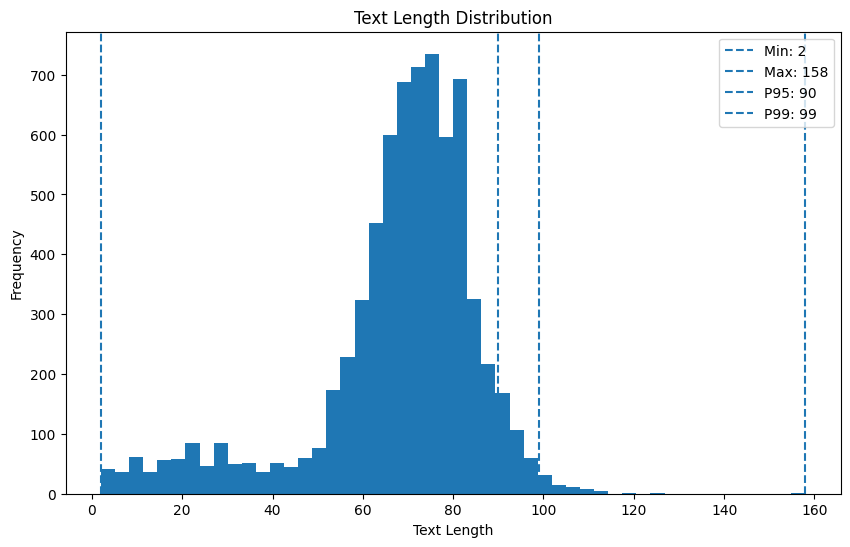

In [4]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
plt.hist(lengths, bins=50)

# vẽ các đường quan trọng
plt.axvline(lengths.min(), linestyle='dashed', label=f"Min: {lengths.min()}")
plt.axvline(lengths.max(), linestyle='dashed', label=f"Max: {lengths.max()}")
plt.axvline(p95, linestyle='dashed', label=f"P95: {int(p95)}")
plt.axvline(p99, linestyle='dashed', label=f"P99: {int(p99)}")

plt.title("Text Length Distribution")
plt.xlabel("Text Length")
plt.ylabel("Frequency")
plt.legend()

plt.show()

# 2. Kích thước ảnh và Tỷ lệ khung hình (Aspect Ratio \& Dimensions)

In [5]:
import os
from PIL import Image
import numpy as np

def get_image_sizes(base_path, label_path):
    widths = []
    heights = []
    
    with open(label_path, 'r', encoding='utf-8') as f:
        for line in f:
            parts = line.strip().split('\t')
            if len(parts) != 2:
                continue
            
            img_rel_path, _ = parts
            img_path = os.path.join(base_path, img_rel_path)
            
            try:
                with Image.open(img_path) as img:
                    w, h = img.size
                    widths.append(w)
                    heights.append(h)
            except:
                continue  # bỏ qua ảnh lỗi
    
    return np.array(widths), np.array(heights)

# Đường dẫn
train_base_path = "/kaggle/input/datasets/khangphantrnvn/uit-handwriten-dataset/UIT_HWDB_line_converted/train_data"
train_label_path = "/kaggle/input/datasets/khangphantrnvn/uit-handwriten-dataset/UIT_HWDB_line_converted/train_data/labels.txt"

widths, heights = get_image_sizes(train_base_path, train_label_path)

print("Số ảnh đọc được:", len(widths))

Số ảnh đọc được: 7028


In [6]:
aspect_ratios = widths / heights

print("Min ratio:", aspect_ratios.min())
print("Max ratio:", aspect_ratios.max())
print("Mean ratio:", aspect_ratios.mean())

Min ratio: 1.012858555885262
Max ratio: 28.444444444444443
Mean ratio: 13.18965683327078


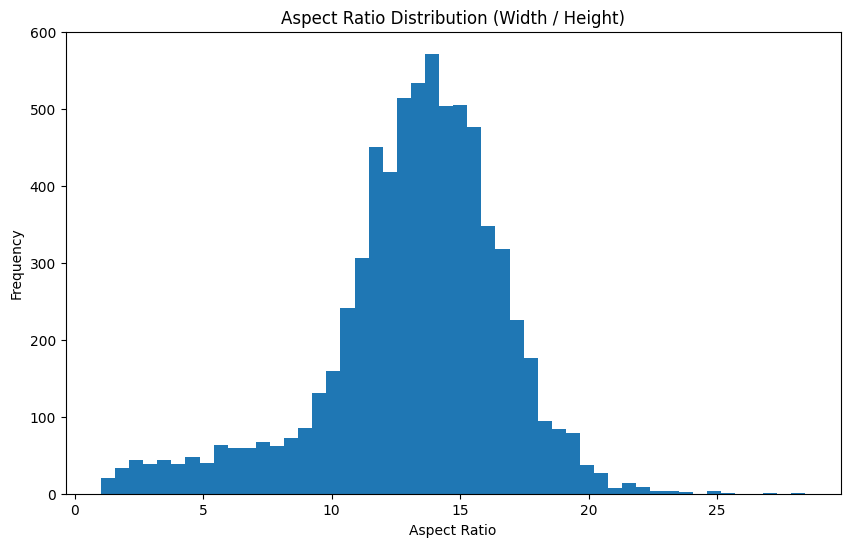

In [7]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
plt.hist(aspect_ratios, bins=50)

plt.title("Aspect Ratio Distribution (Width / Height)")
plt.xlabel("Aspect Ratio")
plt.ylabel("Frequency")

plt.show()

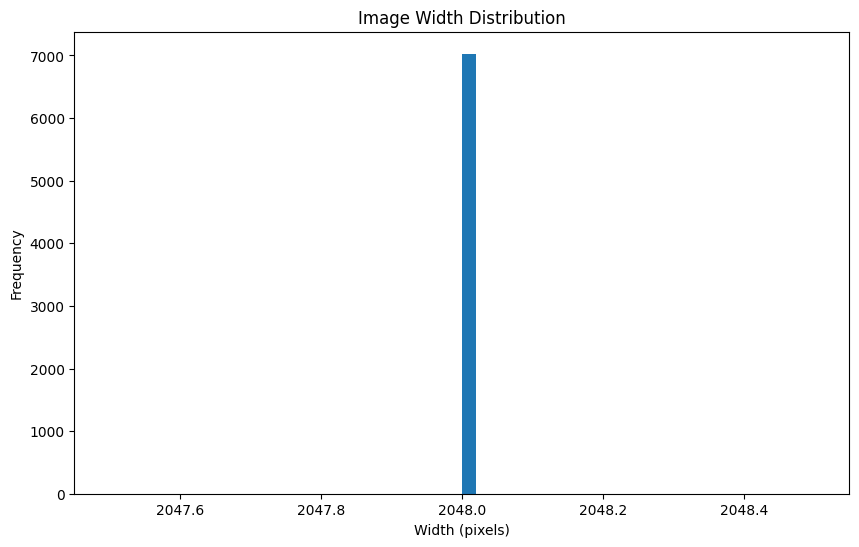

In [8]:
plt.figure(figsize=(10,6))
plt.hist(widths, bins=50)

plt.title("Image Width Distribution")
plt.xlabel("Width (pixels)")
plt.ylabel("Frequency")

plt.show()

In [9]:
p95_w = np.percentile(widths, 95)
p99_w = np.percentile(widths, 99)

print("Width P95:", p95_w)
print("Width P99:", p99_w)
print("Max Width:", widths.max())

Width P95: 2048.0
Width P99: 2048.0
Max Width: 2048


# 3. Tương quan Kích thước ảnh và Độ dài nhãn (Character Density)

In [10]:
text_lengths = np.array([len(t) for t in texts])

# tránh chia cho 0
valid_idx = text_lengths > 0

text_lengths = text_lengths[valid_idx]
widths_valid = widths[valid_idx]

# mật độ ký tự (pixel / char)
density = widths_valid / text_lengths

print("Density stats:")
print("Min:", density.min())
print("Max:", density.max())
print("Mean:", density.mean())

Density stats:
Min: 12.962025316455696
Max: 1024.0
Mean: 39.026973907717284


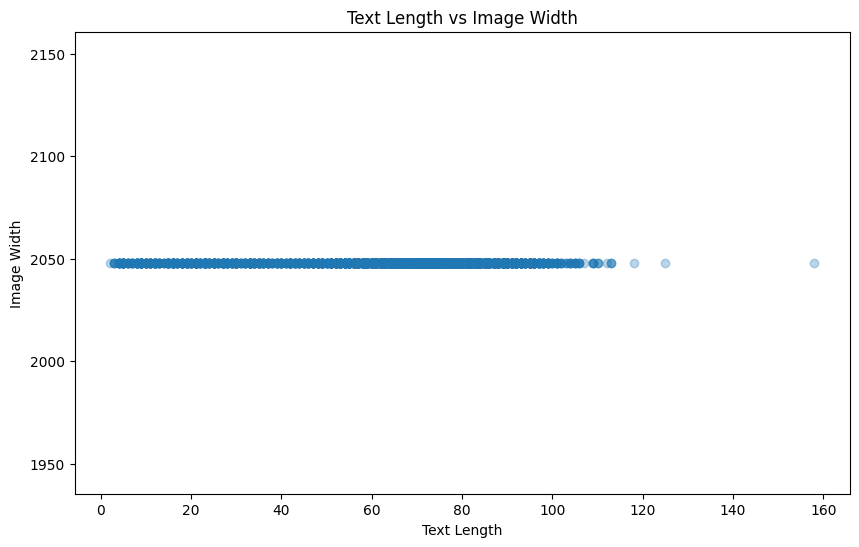

In [11]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

plt.scatter(text_lengths, widths_valid, alpha=0.3)

plt.xlabel("Text Length")
plt.ylabel("Image Width")
plt.title("Text Length vs Image Width")

plt.show()

# 4. Bộ từ vựng và Tần suất ký tự (Vocabulary \& Character Frequency)

In [12]:
from collections import Counter
import unicodedata

char_counter = Counter()

for text in texts:
    text = unicodedata.normalize('NFC', text)
    char_counter.update(list(text))

In [13]:
top_chars = char_counter.most_common(20)

for char, freq in top_chars:
    print(repr(char), ":", freq)

' ' : 103471
'n' : 42110
'h' : 30223
't' : 20647
'i' : 20324
'c' : 20240
'g' : 20199
'a' : 9627
'u' : 9563
'đ' : 9183
'm' : 8435
'à' : 7766
'ư' : 6580
'o' : 6507
'r' : 5865
'l' : 5734
'.' : 5642
'v' : 5557
',' : 5328
'y' : 5153


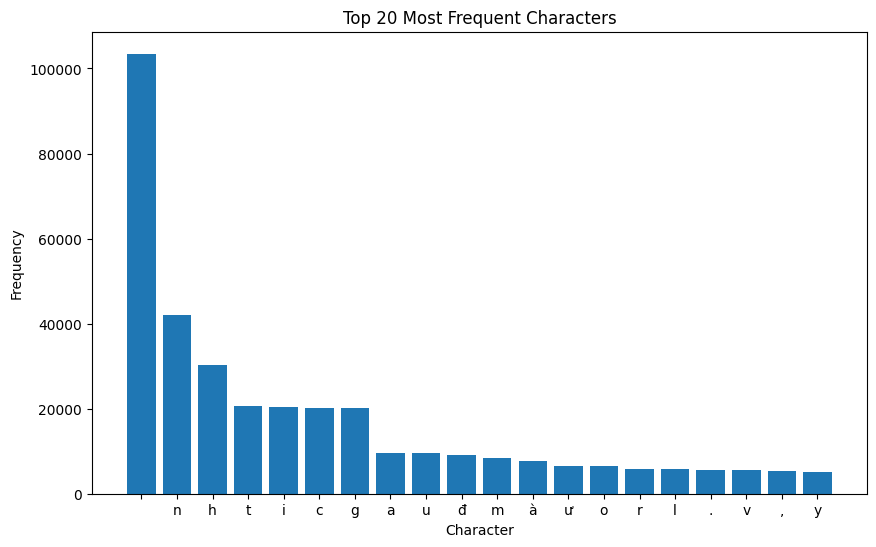

In [14]:
import matplotlib.pyplot as plt

chars = [c for c, _ in top_chars]
freqs = [f for _, f in top_chars]

plt.figure(figsize=(10,6))
plt.bar(chars, freqs)

plt.title("Top 20 Most Frequent Characters")
plt.xlabel("Character")
plt.ylabel("Frequency")

plt.show()

In [15]:
valid_chars = sorted(char_counter.keys())

with open("character_dict.txt", "w", encoding="utf-8") as f:
    for c in valid_chars:
        f.write(c + "\n")

In [16]:
print("Tổng vocab:", len(valid_chars))

Tổng vocab: 161


In [17]:
use_space_char = True

In [18]:
num_classes = len(valid_chars) + 1  # +1 cho CTC blank

In [19]:
import unicodedata

def normalize_text(text):
    return unicodedata.normalize('NFC', text)

texts = [normalize_text(t) for t in texts]

In [20]:
before = set("".join(texts))

texts_norm = [unicodedata.normalize('NFC', t) for t in texts]
after = set("".join(texts_norm))

print("Before:", len(before))
print("After:", len(after))

Before: 161
After: 161


# 5. Chia train - val -test

Tong so mau train_data (goc): 7,028
Text length  min=2  max=158  mean=67.8

Sau khi chia:
  Train split : 6,325 mau (90.0%)
  Val   split : 703  mau (10.0%)
  Test  split : 201  mau (tap doc lap)

Kiem tra phan bo text_len (mean / std):
  Train  mean=67.83  std=18.49
  Val    mean=67.66  std=18.52
  Test   mean=65.18  std=18.21


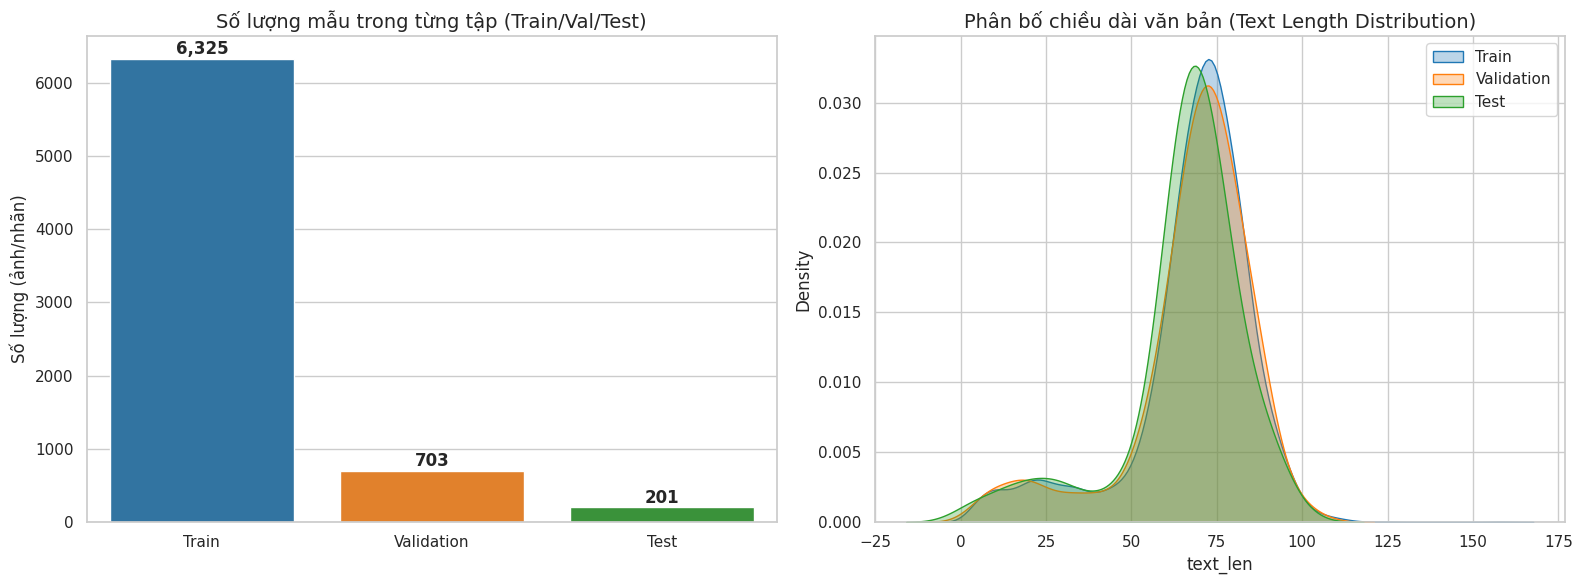


Da ghi:
  /kaggle/working/train_split_gt.txt
  /kaggle/working/val_split_gt.txt

Luu y: tap test_data goc KHONG duoc cham vao trong qua trinh training.


In [31]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import StratifiedShuffleSplit

DATA_ROOT = "/kaggle/input/datasets/khangphantrnvn/uit-handwriten-dataset/UIT_HWDB_line_converted/"
TRAIN_LABEL = "/kaggle/working/train_split_gt.txt"
VAL_LABEL = "/kaggle/working/val_split_gt.txt"
TEST_LABEL = "/kaggle/input/datasets/khangphantrnvn/uit-handwriten-dataset/UIT_HWDB_line_converted/test_data/labels.txt"

# --- Hàm phụ trợ đọc file label ---
def load_labels_to_df(label_path):
    rows = []
    with open(label_path, 'r', encoding='utf-8') as fh:
        for line in fh:
            line = line.strip()
            if '\t' not in line:
                continue
            img_rel, label = line.split('\t', 1)
            rows.append({'img_rel': img_rel, 'label': label, 'text_len': len(label)})
    return pd.DataFrame(rows)

# --- 1. Đọc file nhãn gốc của tập train_data và test_data ---
df = load_labels_to_df(os.path.join(DATA_ROOT, 'train_data', 'labels.txt'))
df_test = load_labels_to_df(TEST_LABEL)

print(f'Tong so mau train_data (goc): {len(df):,}')
print(f'Text length  min={df.text_len.min()}  max={df.text_len.max()}  mean={df.text_len.mean():.1f}')

# --- 2. Tạo strata bằng pd.qcut (10 nhóm theo text length) ---
df['len_bin'] = pd.qcut(df['text_len'], q=10, labels=False, duplicates='drop')

# --- 3. StratifiedShuffleSplit 90/10 ---
sss = StratifiedShuffleSplit(n_splits=1, test_size=0.10, random_state=42)
train_idx, val_idx = next(sss.split(df, df['len_bin']))

df_train = df.iloc[train_idx].reset_index(drop=True)
df_val   = df.iloc[val_idx].reset_index(drop=True)

print(f'\nSau khi chia:')
print(f'  Train split : {len(df_train):,} mau ({len(df_train)/len(df)*100:.1f}%)')
print(f'  Val   split : {len(df_val):,}  mau ({len(df_val)/len(df)*100:.1f}%)')
print(f'  Test  split : {len(df_test):,}  mau (tap doc lap)')

# --- 4. Kiểm tra phân bố text length giữa 3 tập ---
print('\nKiem tra phan bo text_len (mean / std):')
print(f'  Train  mean={df_train.text_len.mean():.2f}  std={df_train.text_len.std():.2f}')
print(f'  Val    mean={df_val.text_len.mean():.2f}  std={df_val.text_len.std():.2f}')
print(f'  Test   mean={df_test.text_len.mean():.2f}  std={df_test.text_len.std():.2f}')

# ==========================================
# --- 5. TRỰC QUAN HÓA (VISUALIZATION) ---
# ==========================================
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Biểu đồ 1: Số lượng mẫu
splits = ['Train', 'Validation', 'Test']
counts = [len(df_train), len(df_val), len(df_test)]

# Fix lỗi bằng cách gán x=splits, hue=splits và legend=False
sns.barplot(
    x=splits, 
    y=counts, 
    hue=splits,               # Gán hue bằng chính biến x
    ax=axes[0], 
    palette=['#1f77b4', '#ff7f0e', '#2ca02c'],
    legend=False              # Tắt chú thích vì trục X đã ghi rõ tên tập dữ liệu
)

axes[0].set_title('Số lượng mẫu trong từng tập (Train/Val/Test)', fontsize=14)
axes[0].set_ylabel('Số lượng (ảnh/nhãn)')

# Thêm con số cụ thể trên đầu mỗi cột
for i, v in enumerate(counts):
    axes[0].text(i, v + (max(counts) * 0.01), f"{v:,}", ha='center', fontweight='bold')

# Biểu đồ 2: Phân bố chiều dài văn bản
sns.kdeplot(data=df_train, x="text_len", ax=axes[1], color='#1f77b4', label='Train', fill=True, alpha=0.3)
sns.kdeplot(data=df_val, x="text_len", ax=axes[1], color='#ff7f0e', label='Validation', fill=True, alpha=0.3)
sns.kdeplot(data=df_test, x="text_len", ax=axes[1], color='#2ca02c', label='Test', fill=True, alpha=0.3)
axes[1].set_title('Phân bố chiều dài văn bản (Text Length Distribution)', fontsize=14)
axes[1].legend()

plt.tight_layout()
plt.show()
# --- 6. Ghi ra 2 file nhãn ---
os.makedirs(os.path.dirname(TRAIN_LABEL) or '.', exist_ok=True)

with open(TRAIN_LABEL, 'w', encoding='utf-8') as fh:
    for _, row in df_train.iterrows():
        fh.write(f"{row['img_rel']}\t{row['label']}\n")

with open(VAL_LABEL, 'w', encoding='utf-8') as fh:
    for _, row in df_val.iterrows():
        fh.write(f"{row['img_rel']}\t{row['label']}\n")

print(f'\nDa ghi:')
print(f'  {TRAIN_LABEL}')
print(f'  {VAL_LABEL}')
print('\nLuu y: tap test_data goc KHONG duoc cham vao trong qua trinh training.')